# 🫁 Pneumonia X-Ray Classification Using PyTorch And ResNet18

This Project Uses A Deep Learning Model Based On ResNet18 To Classify Chest X-Ray Images Into Two Categories:

- Normal
- Pneumonia

Dataset:
https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

The Dataset Is Downloaded Using KaggleHub.

Default Training Uses Five Epochs To Keep Training Accessible For CPU And Google Colab Users.

Increasing The Number Of Epochs May Improve Accuracy.

Developed For AltayBioAI.

Install KaggleHub:

In [1]:
!pip install -q kagglehub

Imports:

In [2]:
import kagglehub
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18
import matplotlib.pyplot as plt
from google.colab import files

Download Dataset:

In [3]:
path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print(path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia


Explore Dataset:

In [4]:
for root, dirs, files_ in os.walk(path):
    print(root)
    print(dirs)
    print()

/kaggle/input/chest-xray-pneumonia
['chest_xray']

/kaggle/input/chest-xray-pneumonia/chest_xray
['chest_xray', '__MACOSX', 'val', 'test', 'train']

/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray
['val', 'test', 'train']

/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val
['PNEUMONIA', 'NORMAL']

/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA
[]

/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL
[]

/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test
['PNEUMONIA', 'NORMAL']

/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test/PNEUMONIA
[]

/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL
[]

/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train
['PNEUMONIA', 'NORMAL']

/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train/PNEUMONIA
[]

/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL
[]

/kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX
['che

Dataset Paths:

In [5]:
train_path = os.path.join(
    path,
    "chest_xray",
    "train"
)

test_path = os.path.join(
    path,
    "chest_xray",
    "test"
)

Dataset Test:

In [7]:
print(os.listdir(train_path))
print(os.listdir(test_path))

['PNEUMONIA', 'NORMAL']
['PNEUMONIA', 'NORMAL']


Image Transformations:

In [8]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.5],
        [0.5]
    )
])

Load Dataset:

In [9]:
train_dataset = ImageFolder(
    train_path,
    transform=transform
)

test_dataset = ImageFolder(
    test_path,
    transform=transform
)

Dataset Information:

In [10]:
print(
    "Training Images:",
    len(train_dataset)
)

print(
    "Test Images:",
    len(test_dataset)
)

print(
    "Classes:",
    train_dataset.classes
)

Training Images: 5216
Test Images: 624
Classes: ['NORMAL', 'PNEUMONIA']


DataLoader:

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

Show Images:

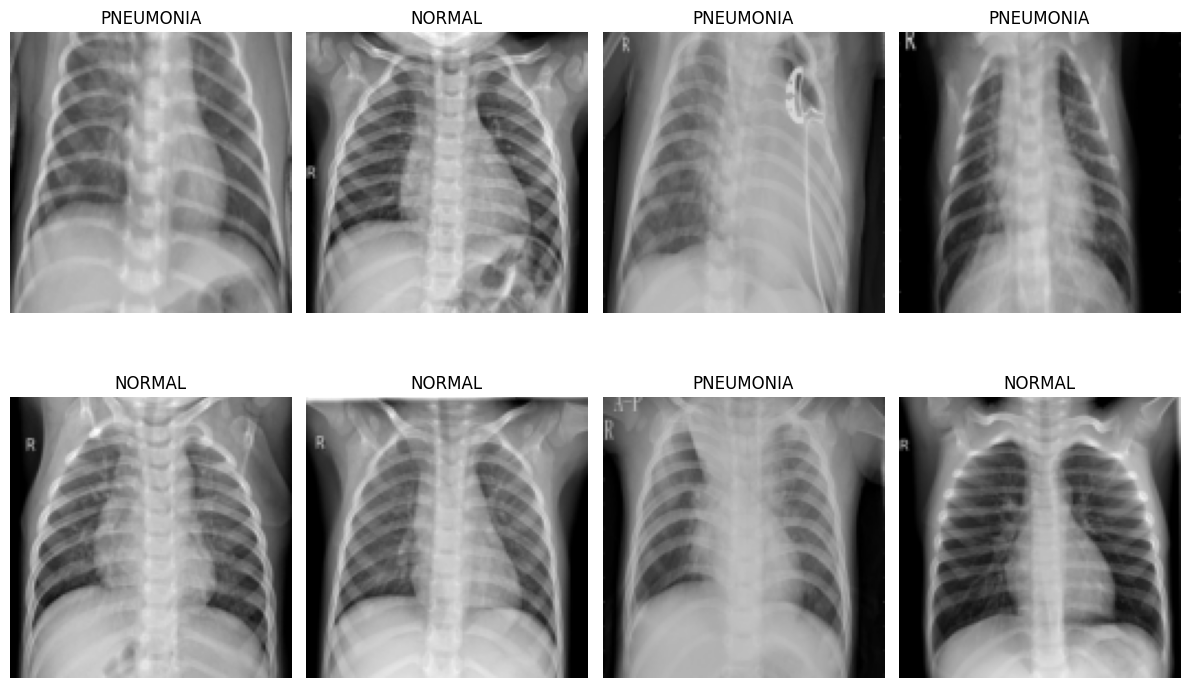

In [12]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(12,8))

for i in range(8):
    plt.subplot(2,4,i+1)
    img = images[i].permute(1,2,0)
    img = img * 0.5 + 0.5
    plt.imshow(
        img.squeeze(),
        cmap="gray"
    )
    plt.title(
        train_dataset.classes[
            labels[i]
        ]
    )
    plt.axis("off")

plt.tight_layout()

plt.show()

Device:

In [13]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


Model:

In [14]:
model = resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    2
)

model = model.to(device)

Loss And Optimizer:

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

Training:

Training
Each Epoch May Take Several Minutes.
Increasing The Number Of Epochs May Improve Accuracy.
Epochs = 5

In [22]:
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(
            outputs,
            labels
        )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    print(
        f"Epoch {epoch+1}/{epochs}"
        f" - Loss: {epoch_loss:.4f}"
    )

Epoch 1/5 - Loss: 0.0242
Epoch 2/5 - Loss: 0.0260
Epoch 3/5 - Loss: 0.0179
Epoch 4/5 - Loss: 0.0237
Epoch 5/5 - Loss: 0.0225


Accuracy:

In [23]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(
            outputs,
            1
        )
        total += labels.size(0)
        correct += (
            predicted == labels
        ).sum().item()

accuracy = 100 * correct / total

print(
    f"Accuracy: {accuracy:.2f}%"
)

Accuracy: 77.88%


Predictions:

In [24]:
images, labels = next(iter(test_loader))
images_device = images.to(device)

model.eval()

with torch.no_grad():
    outputs = model(images_device)
    _, predictions = torch.max(
        outputs,
        1
    )

Show Predictions:

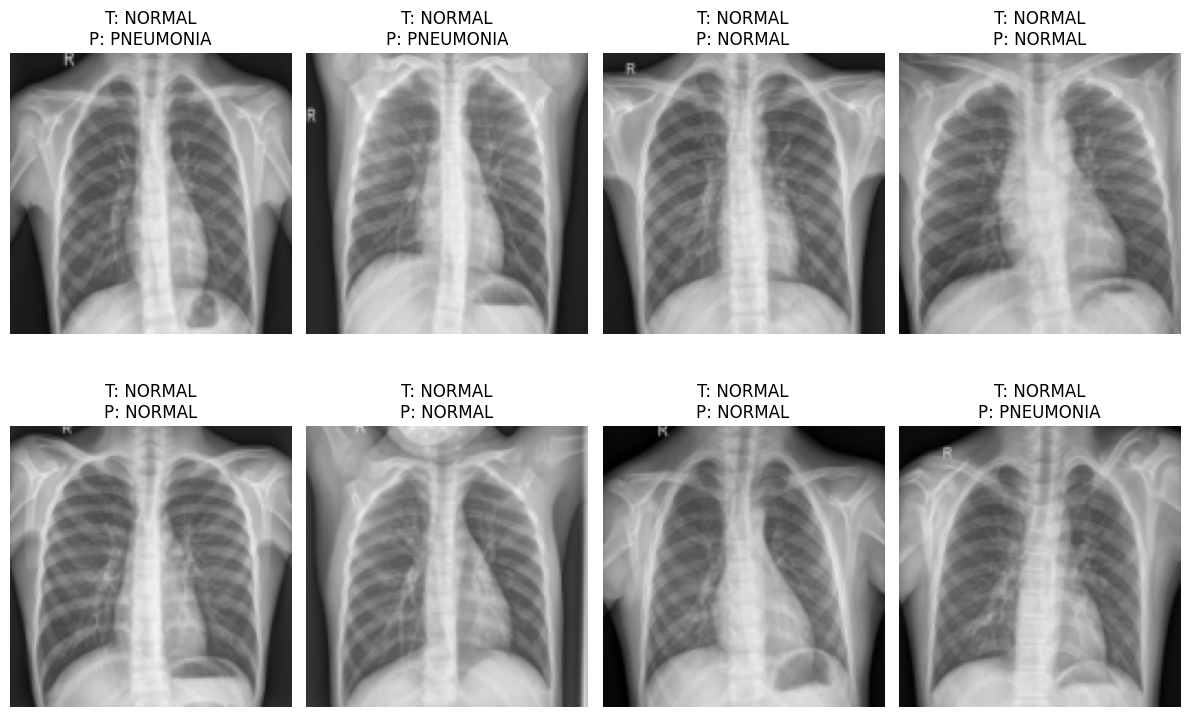

In [25]:
plt.figure(figsize=(12,8))

for i in range(8):
    plt.subplot(2,4,i+1)
    img = images[i].permute(1,2,0)
    img = img * 0.5 + 0.5
    plt.imshow(
        img.squeeze(),
        cmap="gray"
    )
    true_label = train_dataset.classes[
        labels[i]
    ]
    pred_label = train_dataset.classes[
        predictions[i].cpu()
    ]
    plt.title(
        f"T: {true_label}\nP: {pred_label}"
    )
    plt.axis("off")

plt.tight_layout()

plt.show()

Save Model:

In [26]:
torch.save(
    model.state_dict(),
    "pneumonia_resnet18.pth"
)

Download Model:

In [27]:
files.download(
    "pneumonia_resnet18.pth"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Finish:

In [28]:
print(
    "Training Completed Successfully."
)

print(
    f"Final Accuracy: {accuracy:.2f}%"
)

Training Completed Successfully.
Final Accuracy: 77.88%
